## 1D Fiting with SASView from notebook
## trucated_octahedron model template notebook

* import all the packages
* install packages before using a separate notebook
* better to work in a dedicated python environnement

In [30]:
import numpy as np

import sasmodels
import sasmodels.core
import sasmodels.data
import sasmodels.bumps_model

import sasdata

from sasdata.dataloader.loader import Loader
from sasmodels.data import load_data
from sasmodels.data import plot_theory

import bumps
import bumps.fitters
import bumps.names
import bumps.fitproblem

import os


* configuration of matplotlib for plots 

In [31]:
"""
import matplotlib.pyplot and set custom default settings for plots
"""
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import matplotlib.pyplot as plt

plt.rc('font', size=14) 
plt.rc('axes', titlesize=16)
plt.rc('axes', labelsize=16)
plt.rc('xtick', labelsize=14)
plt.rc('ytick', labelsize=14)
plt.rc('legend', fontsize=14)
plt.rc('legend', title_fontsize=14)
plt.rc('figure', titlesize=18)
plt.rc("figure", figsize=(5,5))
plt.rc("lines", linewidth=3)

### Load a 1D data file

* load an experimental data file .dat 
* define here filename and path on your computer

In [32]:
filenameraw= "./data-examples/RN54Tet-oct23.dat"
#filename='./data-examples/SWING-mn1-00169{00028}_AzInt_Px_28.dat'

#filename="./data-examples/0V_00228.dat"

* subtraction from empty file

In [33]:
fileempty="./data-examples/CTAC_2p5-oct23.dat"

total number of data points:  1216


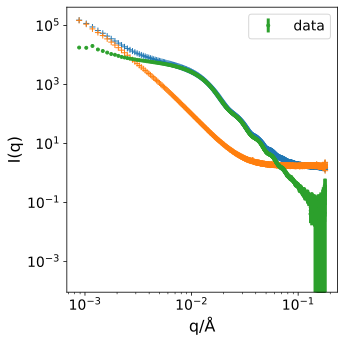

In [34]:
#number of lines in the header
skipheader=25 

# Using loadtxt to load data
data_np = np.loadtxt(filenameraw, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')
# datasub incorporates the subtraction of empty file
coeffempty=0.9
empty_np = np.loadtxt(fileempty, skiprows=skipheader)

plt.loglog(empty_np[:,0], empty_np[:,1], '+')
datasub= sasmodels.data.Data1D(x=data_np[0:total_data_number,0], 
                             y=data_np[0:total_data_number,1]-coeffempty*empty_np[0:total_data_number,1], 
                             dy=data_np[0:total_data_number,2])




sasmodels.data.plot_data(datasub)


In [35]:
subfilename=filenameraw[:-4]+"_sub.dat" # data 

with open(subfilename, "w") as f:
    f.write("raw data file is:"+filenameraw+"\n")
    f.write("number of data points: \t"+str(total_data_number)+"\n")

with open(subfilename, "a") as fa:
    for i in range(0,total_data_number):
        line_to_write=str(datasub.x[i])+"\t"+str(datasub.y[i])+"\t"+str(datasub.dy[i])+"\n"
        fa.write(line_to_write)

when no subtraction 

In [36]:
filename= "./data-examples/RN54Tet-oct23_sub.dat"
#filename='./data-examples/SWING-mn1-00169{00028}_AzInt_Px_28.dat'

#filename="./data-examples/0V_00228.dat"

Process the data file:
* use `skipheader` to skip the header 
* use `skipmin` to skip data points at low q values
* use `skipmax` to skip data points at large q values
* load the data in a numpy array and show a first plot
* use `slicing_step` to reduce the number of data points (slicing_step=3 means that 1 point over 3 is taken)
* use `rescale` the intensity coefficient for rescaling (in cm-1) if not done previously
* use `coeff` to compute realistic error bars as a percentage of intensity values (coeff=0.1 means 10% of intensity error bars)
* transform the numpy array into a suitable 1D data set using `sasmodels.data.Data1D`
* data plot shows the complete data `data_np` set and the new one `data`

total number of data points:  1193
after skip at low and large q values: 443
after slicing: 222


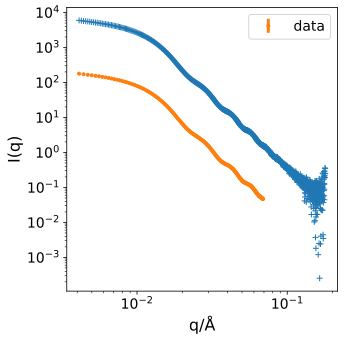

In [37]:
#number of lines in the header
skipheader=25 

# Using loadtxt to load data
data_np = np.loadtxt(filename, skiprows=skipheader)

total_data_number=data_np.shape[0] #total number of data points in the file
print('total number of data points: ',total_data_number)

plt.loglog(data_np[:,0], data_np[:,1], '+')


#number of points to skip at low q values
skipmin=0
data_np = np.loadtxt(filename, skiprows=skipheader+skipmin)

# number of data point to skip at the end
skipmax=750
number_of_data=total_data_number-skipmax-skipmin

print('after skip at low and large q values:', number_of_data)

slicing_step=2 # step of slicing 

# rescaling of intensity values
# TP UE soft matter 2026
# scaling factor from SWING to Cu-SAXS to be in cm-1
rescale=0.03

# new error bars: 10 % of intensity values
coeff=0.04

data = sasmodels.data.Data1D(x=data_np[0:number_of_data:slicing_step,0], 
                             y=rescale*data_np[0:number_of_data:slicing_step,1], 
                             dy=rescale*coeff*data_np[0:number_of_data:slicing_step,1])



number_of_data_new=data.x.shape[0]
print('after slicing:', number_of_data_new)

sasmodels.data.plot_data(data)



* plot of the new data set `data`

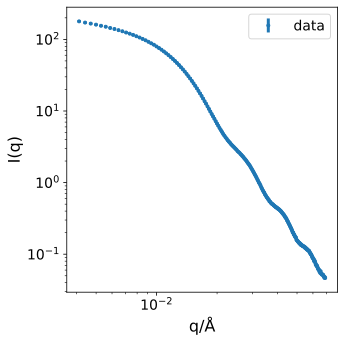

In [38]:
sasmodels.data.plot_data(data)

### save `data` in a new data file
* add `_new`at the end of the name

In [39]:
newfilename=filename[:-4]+"_new.dat" # data 

with open(newfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(newfilename, "a") as fa:
    for i in range(0,number_of_data_new):
        line_to_write=str(data.x[i])+"\t"+str(data.y[i])+"\t"+str(data.dy[i])+"\n"
        fa.write(line_to_write)

In [40]:
qstart = data.x[0]
print(qstart)

0.0041130142094083985


In [41]:
qend = data.x[number_of_data_new-1]
print(qend)

0.06903655682223728


In [42]:
Istart = data.y[0]
print(Istart)

178.46962639191455


In [43]:
Iend = data.y[number_of_data_new-1]
print(Iend)

0.04658250139152781


### fit the data

* create the computation `kernel` selecting the `cylinder` model
* create the `model` interfaced with bump module
* create the `experiment`, containing both data and model

In [44]:

kernel = sasmodels.core.load_model("truncated_tetrahedron")
params = {} # default parameters for now
model = sasmodels.bumps_model.Model(kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

* default values of all parameters

In [45]:
kernel.info.parameters.defaults

{'scale': 1,
 'background': 0.001,
 'sld': 126.0,
 'sld_solvent': 9.4,
 'radius': 100,
 'truncation': 0}

#### preliminary step: manual adjustment of parameters before fiting

Don't forget updating the SLD values (x10-6 A-2) !
* gold: 125
* silver: 77.9
* water: 9.47
* toluene: 8.4

In [46]:
sld_gold=125
sld_silver=77.9
sld_water=9.47
sld_toluene=8.4

Model name = truncated_tetrahedron

In [47]:
model_name = "truncated_tetrahedron"

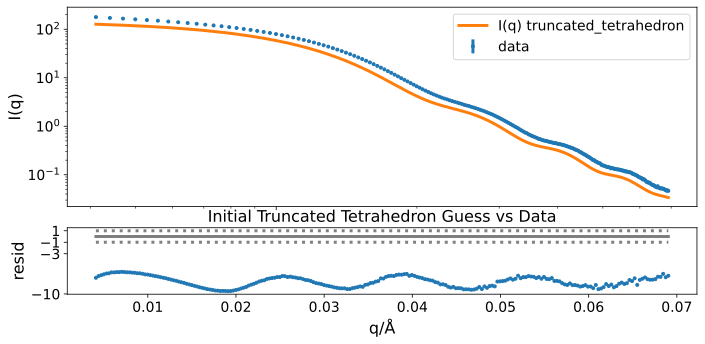

In [48]:
  

params = {
    # --- 1. PRIMARY DIMENSION ---
    "radius": 380,  
    "radius_pd_type": 'gaussian', 
    "radius_pd": 0.05, 
    "radius_pd_n": 8, 
    "radius_pd_nsigma": 3,
    
   
    "truncation": 0.22, # Starting guess for truncation 
    
    # --- 3. SCATTERING CONTRAST & BACKGROUND ---
    "sld": sld_gold,         
    "sld_solvent": sld_water,
    "background": 0,
    "scale": 0.000004
}

# Build the model and experiment
model = sasmodels.bumps_model.Model(model=kernel, **params)
experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

# Plot the initial guess against your data
plt.figure(figsize=(10, 5))
experiment.plot()
plt.title("Initial Truncated Tetrahedron Guess vs Data")
plt.show()

### Explanation of the polydispersity parameters

The polydispersity is set using a special set of \*\_pd\_\* parameters:
* `*_pd*` is the width of the polydispersity and the exact definition will depend on the type of distribution specified; in this cause of a 'gaussian` distribution, it is defined as as $\frac{\sigma}{x_{mean}}$
* `*_pd_type*` defines the type of polydispersity distribution used
* `*_pd_n` corresponds to the the number of points in the distribution used by the calculation (Npts in the image below)
* `*_pd_nsigma` sets the range of the distribution sampled (Nsigmas in the image below)

For example, radius polydispersity could be defined by specifying **all four** of the pd parameters. With the default values, this would look like:
* `radius_pd = 0`
* `radius_pd_type = 'gaussian'`
* `radius_pd_n = 35`
* `radius_pd_nsigma = 3`

The available polydispersity distributions are defined in the SasView [documentation](https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html) but we can access them directly through the sasmodels `weights` module.

The 'gaussian' distribution is claculed by:

$$
f(x) = \frac{1}{Norm}\exp\left(-\frac{(x-x_{mean})^2}{2\sigma^2}\right)
$$

<img src=https://www.sasview.org/docs/_images/pd_gaussian.jpg>

*Image source: https://www.sasview.org/docs/user/qtgui/Perspectives/Fitting/pd/polydispersity.html*


## fiting the data

* choice of the initial values for parameters
* choice of the fiting parameters with their fiting range

step 1 cost 63.849(22)
                                  radius .....|....        380 in [350, 400]
                               radius_pd ....|.....       0.05 in [0.03, 0.07]
                                   scale |.........      4e-06 in [1e-06, 0.0001]
                              truncation .......|..       0.22 in [0, 0.3]
step 2 cost 0.726(22)
step 3 cost 0.263(22)
step 4 cost 0.259(22)
step 5 cost 0.259(22)
step 5 cost 0.259(22) [final]
                                  radius ...|......    367.035 in [350, 400]
                               radius_pd ......|...  0.0546127 in [0.03, 0.07]
                                   scale |......... 5.7037e-06 in [1e-06, 0.0001]
                              truncation .......|..   0.218461 in [0, 0.3]
time 20 seconds
Fit results for problem: χ² = 0.259(22)
=== Uncertainty from curvature:     name   value(unc.) ===
                                  radius   367.04(80)     
                               radius_pd   0.0546(30)     


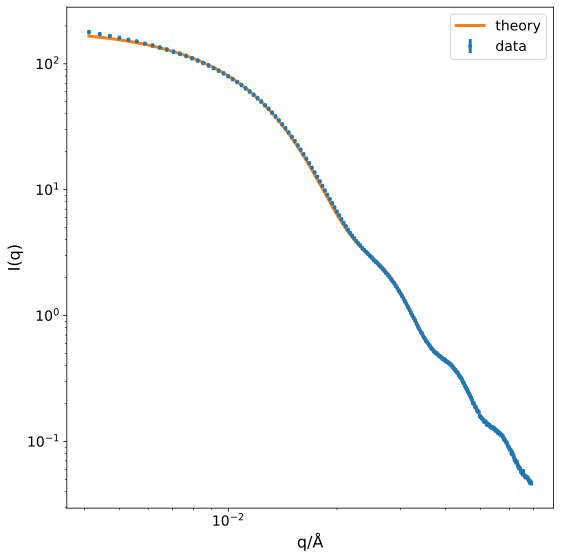

In [49]:
model = sasmodels.bumps_model.Model(model=kernel, **params)


model.scale.range(1e-6,1e-4)      
#model.background.range(1e-7, 1e-5)   
model.radius.range(350, 400)          
model.radius_pd.range(0.03, 0.07)
model.truncation.range(0, 0.3)          
#model.length_pd.range(0.0, 0.2)

 

experiment = sasmodels.bumps_model.Experiment(data=data, model=model)

problem = bumps.fitproblem.FitProblem(experiment)

results = bumps.fitters.fit(problem, 
                            method='lm', 
                            steps=20,   
                            ftol=1.5e-06, 
                            xtol=1.5e-06, 
                            verbose=True)

plt.figure(figsize=(8,8))
print(problem.summarize())
print(model.state())
print(f"Chi-Squared: {problem.chisq()}")
sasmodels.data.plot_theory(data,experiment.Iq_calc)

In [50]:
print(model.state())
print(problem.summarize())
print(problem.chisq())




{'scale': 5.7037030260687925e-06, 'background': 0.0, 'sld': 125.0, 'sld_solvent': 9.47, 'radius': 367.03536104599846, 'radius_pd': 0.054612747117961054, 'radius_pd_n': 8.0, 'radius_pd_nsigma': 3.0, 'truncation': 0.21846092777437148, 'truncation_pd': 0.0, 'truncation_pd_n': 35.0, 'truncation_pd_nsigma': 3.0, 'radius_pd_type': 'gaussian', 'truncation_pd_type': 'gaussian'}
                                  radius ...|......    367.035 in [350, 400]
                               radius_pd ......|...  0.0546127 in [0.03, 0.07]
                                   scale |......... 5.7037e-06 in [1e-06, 0.0001]
                              truncation .......|..   0.218461 in [0, 0.3]
0.25869205652988486


* store the fited values in R_fit and L_fit

In [51]:
# value of R after fiting
R_ave_fit=model.radius.value

# value of Thickness after fiting (Replaces L_fit)
L_fit=model.radius_pd.value

#### Save the fited curve in a file
* `_fit` is added at the end of filename

In [52]:
fitfilename=filename[:-4]+"_fit.dat" # fit 

with open(fitfilename, "w") as f:
    f.write("raw data file is:"+filename+"\n")
    f.write("number of data points: \t"+str(number_of_data_new)+"\n")

with open(fitfilename, "a") as fa:
    for i in range(0,number_of_data_new-1):
        line_to_write=str(data.x[i])+"\t"+str(experiment.Iq_calc[i])+"\n"
        fa.write(line_to_write)

### final plot
* use this one for a nice .svg output

0.25869205652988486


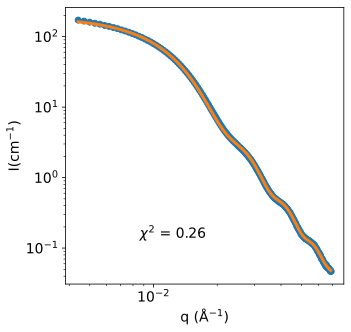

In [53]:
data_final = np.loadtxt(newfilename, skiprows=3)

fit_final = np.loadtxt(fitfilename, skiprows=3)

plt.loglog(data_final[:,0], data_final[:,1], 'o')
plt.loglog(fit_final[:,0], fit_final[:,1])
plt.xlabel('q '+r'(Å$^{-1}$)',fontsize=14)
plt.ylabel('I'+r'(cm$^{-1}$)',fontsize=14)
plt.text(qstart*3,Iend*3,r'$\chi^2$ = '+f"{problem.chisq():.2f}",fontsize=14,horizontalalignment='center')
print(problem.chisq())
